# AI Bias Awareness: The COMPAS Case Study
### *How Artificial Intelligence Can Amplify Human Injustice*

---

**Requirements:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`

```
pip install pandas numpy matplotlib seaborn scikit-learn
```

**Dataset:** COMPAS Recidivism Dataset — Broward County, Florida (ProPublica / Kaggle)  
**Reference:** Kaggle AI Ethics Course — *"Identifying Bias in AI"* by Alexis Cook

---

---
# Part 1 — Introduction: "Can We Trust AI?"

---

## The Illusion of Objectivity

There is a seductive idea that runs through our culture: **AI is objective.** Unlike humans — who are emotional, inconsistent, and prone to prejudice — a machine learning model is just math. Numbers go in, numbers come out. No anger, no fatigue, no racism.

This idea is **dangerously wrong.**

Machine learning models do not reason from first principles. They **learn from data** — historical records of human decisions. If those records reflect centuries of systemic inequality, the model doesn't transcend that inequality. It absorbs it, codifies it, and scales it up. The bias stops being visible because it's now hidden inside a formula, stamped with the authority of mathematics.

---

## Six Ways AI Becomes Biased

Bias in AI doesn't have a single source. Researchers have identified **six distinct types** that can infect a machine learning system at different stages of its life cycle:

| # | Type | Definition |
|---|------|------------|
| 1 | **Historical Bias** | The world used to generate the data was already unfair. The model learns to replicate past injustice as if it were truth. |
| 2 | **Representation Bias** | Certain groups are underrepresented (or missing) in the training data. The model performs poorly for those it has barely "seen." |
| 3 | **Measurement Bias** | A flawed proxy variable is used in place of what we actually care about. The proxy works differently for different groups, so the model treats them differently without knowing why. |
| 4 | **Aggregation Bias** | Different groups are lumped together and modeled as one. A single model that can't distinguish group-specific patterns will fail the most vulnerable. |
| 5 | **Evaluation Bias** | The benchmarks used to measure a model's performance don't represent all groups, so a biased model looks great on paper. |
| 6 | **Deployment Bias** | The model is used in ways it was never designed for. Even a well-intentioned tool becomes harmful when applied outside its intended scope. |

---

## The Case Study: COMPAS in the Courtroom

In the 2010s, courts across the United States began using an AI tool called **COMPAS** (Correctional Offender Management Profiling for Alternative Sanctions) to help judges decide:

- Should this person be released on bail, or held in jail?
- Should their sentence be longer or shorter?
- Are they likely to reoffend if released?

COMPAS produced a **risk score** from 1 to 10. A score of 8 might mean the difference between going home or staying in a cage. Defendants were generally **not allowed to see** the algorithm behind their score, which was proprietary.

In 2016, **ProPublica** — an investigative journalism organization — obtained COMPAS scores for over 7,000 defendants in Broward County, Florida, then tracked what actually happened to them over the next two years. Their finding was explosive:

> *"Black defendants were nearly twice as likely as white defendants to be falsely flagged as future criminals, while white defendants were more likely than black defendants to be incorrectly flagged as low risk."*  
> — ProPublica, 2016

This notebook will take you through the data, rebuild the experiment, and show — **with our own code and visualizations** — exactly why this happened and what it means.

> **Key Takeaway:** AI is not neutral. It is a mirror of the data it learns from. When that data reflects a biased world, the AI faithfully reflects that bias — and gives it the unearned credibility of algorithmic authority.

---
# Part 2 — Exploring the Data

---

## Loading and Understanding the Dataset

We'll use the `cox-violent-parsed.csv` file from the ProPublica COMPAS dataset. This file merges the original COMPAS scores with court records, allowing us to see both **what COMPAS predicted** and **what actually happened** to each defendant over the following two years.

Key columns we'll use:
- **`race`**: The defendant's recorded racial classification
- **`age`**: Age at time of screening
- **`sex`**: Gender
- **`priors_count`**: Number of prior criminal offenses
- **`c_charge_degree`**: Severity of current charge (felony/misdemeanor)
- **`decile_score`**: COMPAS risk score (1–10; what the algorithm said)
- **`score_text`**: COMPAS risk label (Low / Medium / High)
- **`is_recid`**: Did the person actually reoffend? (1 = yes, 0 = no)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

# ── Colorblind-friendly palette ──────────────────────────────────────────────
CB_PALETTE = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7', '#C4AD66', '#77BEDB']
RACE_COLORS = {
    'African-American': '#D65F5F',
    'Caucasian':        '#4878CF',
    'Hispanic':         '#6ACC65',
    'Other':            '#B47CC7',
    'Asian':            '#C4AD66',
    'Native American':  '#77BEDB',
}

sns.set_theme(style='whitegrid', palette=CB_PALETTE)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Load the dataset
raw = pd.read_csv('archive/cox-violent-parsed.csv')

print(f'Raw dataset shape: {raw.shape[0]:,} rows × {raw.shape[1]} columns')
raw.head(3)

Raw dataset shape: 18,316 rows × 52 columns


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event
0,1.0,miguel hernandez,miguel,hernandez,14/08/2013,Male,18/04/1947,69,Greater than 45,Other,...,Risk of Violence,1,Low,14/08/2013,07/07/2014,14/07/2014,0,0,327,0
1,2.0,miguel hernandez,miguel,hernandez,14/08/2013,Male,18/04/1947,69,Greater than 45,Other,...,Risk of Violence,1,Low,14/08/2013,07/07/2014,14/07/2014,0,334,961,0
2,3.0,michael ryan,michael,ryan,31/12/2014,Male,06/02/1985,31,25 - 45,Caucasian,...,Risk of Violence,2,Low,31/12/2014,30/12/2014,03/01/2015,0,3,457,0


### Data Cleaning

Before we can analyse anything, we need to make sure our data is reliable. We'll perform three cleaning steps:

1. **Select only the columns we need** — this reduces noise and keeps our analysis focused.
2. **Remove rows where `is_recid == -1`** — a value of -1 means the outcome is unknown (e.g., the follow-up period was incomplete). Including these would corrupt our evaluation.
3. **Drop remaining rows with missing values** — a small number of rows are missing charge degree or score information.

In [3]:
FEATURES = ['age', 'sex', 'race', 'priors_count', 'c_charge_degree']
TARGET   = 'is_recid'
SCORE    = 'decile_score'
LABEL    = 'score_text'

df = raw[FEATURES + [TARGET, SCORE, LABEL]].copy()

# Step 1 — Remove unknown outcomes
before = len(df)
df = df[df[TARGET] != -1]
print(f'Removed {before - len(df):,} rows with unknown recidivism outcome (is_recid == -1)')

# Step 2 — Drop remaining nulls
before = len(df)
df = df.dropna()
print(f'Removed {before - len(df):,} additional rows with missing values')

print(f'\nClean dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nColumn types:\n{df.dtypes}')

Removed 820 rows with unknown recidivism outcome (is_recid == -1)
Removed 65 additional rows with missing values

Clean dataset shape: 17,431 rows × 8 columns

Column types:
age                int64
sex                  str
race                 str
priors_count       int64
c_charge_degree      str
is_recid           int64
decile_score       int64
score_text           str
dtype: object


### Basic Statistics

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,17431.0,NaN,NaN,NaN,33.946016,11.596853,18.0,25.0,31.0,41.0,96.0
sex,17431,2,Male,14237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,17431,6,African-American,9393,NaN,NaN,NaN,NaN,NaN,NaN,NaN
priors_count,17431.0,NaN,NaN,NaN,4.110378,5.357873,0.0,1.0,2.0,6.0,43.0
c_charge_degree,17431,14,(F3),10283,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_recid,17431.0,NaN,NaN,NaN,0.480007,0.499614,0.0,0.0,0.0,1.0,1.0
decile_score,17431.0,NaN,NaN,NaN,5.0436,2.929374,1.0,2.0,5.0,8.0,10.0
score_text,17431,3,Low,8087,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Distribution of the Target Variable

We want to understand the overall balance of our outcome variable: how many defendants in this dataset *actually* reoffended within two years, and how many did not?

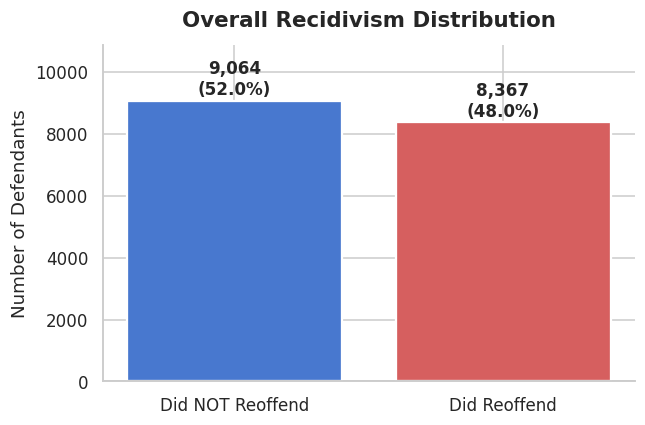

Total defendants: 17,431
Recidivism rate: 48.0%


In [5]:
fig, ax = plt.subplots(figsize=(6, 4))

counts = df[TARGET].value_counts()
labels = ['Did NOT Reoffend', 'Did Reoffend']
colors = ['#4878CF', '#D65F5F']

bars = ax.bar(labels, [counts[0], counts[1]], color=colors, edgecolor='white', linewidth=1.5)

for bar, count in zip(bars, [counts[0], counts[1]]):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Overall Recidivism Distribution', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Number of Defendants')
ax.set_ylim(0, max(counts[0], counts[1]) * 1.2)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Total defendants: {len(df):,}")
print(f"Recidivism rate: {df[TARGET].mean()*100:.1f}%")

The dataset is roughly balanced — about half of defendants did reoffend within two years. This is important: it means a model that blindly predicts "no reoffence" every time would only be right about 50% of the time, so any model with higher accuracy has actually learned *something* from the data. The question is *what* it has learned.

### Racial Breakdown of the Dataset

Before building any model, let's understand who is in this dataset. The racial composition of the sample will directly shape what the model learns.

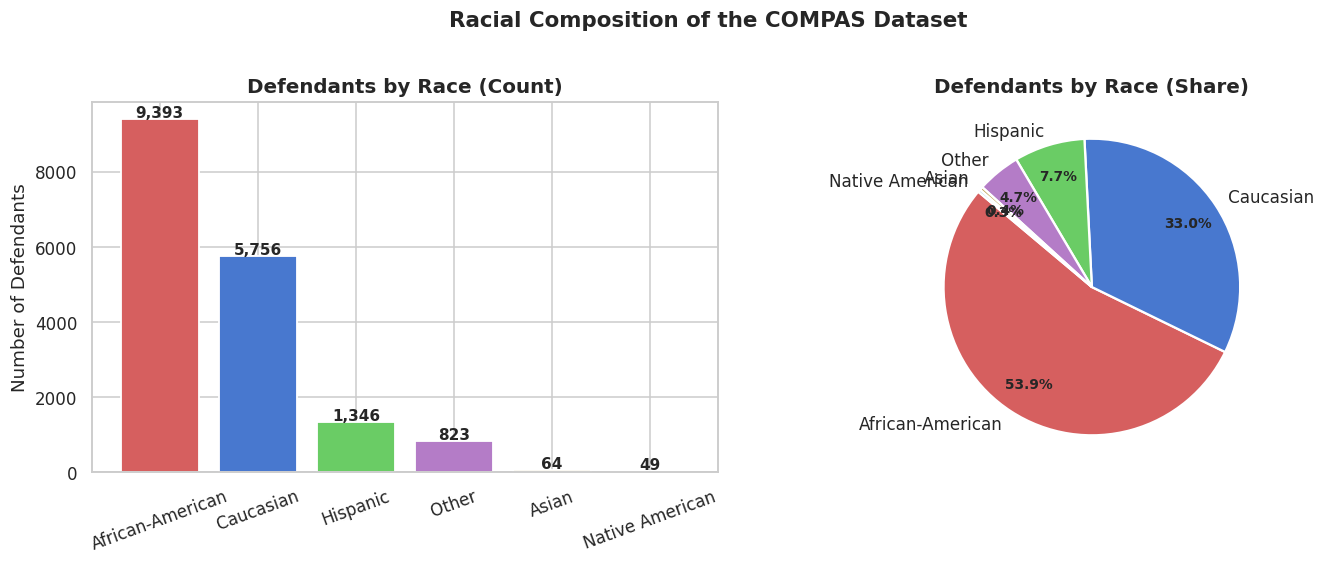

In [6]:
race_counts = df['race'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bar_colors = [RACE_COLORS.get(r, '#999999') for r in race_counts.index]
axes[0].bar(race_counts.index, race_counts.values, color=bar_colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Defendants by Race (Count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Defendants')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)
for i, (val) in enumerate(race_counts.values):
    axes[0].text(i, val + 50, f'{val:,}', ha='center', fontsize=10, fontweight='bold')

# Pie chart
pie_colors = [RACE_COLORS.get(r, '#999999') for r in race_counts.index]
wedges, texts, autotexts = axes[1].pie(
    race_counts.values,
    labels=race_counts.index,
    colors=pie_colors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.78,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for t in autotexts:
    t.set_fontsize(9)
    t.set_fontweight('bold')
axes[1].set_title('Defendants by Race (Share)', fontsize=13, fontweight='bold')

plt.suptitle('Racial Composition of the COMPAS Dataset', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**What we see:** African-American defendants make up the largest group — roughly 53% of the dataset. Caucasian defendants are the second-largest group at ~33%. All other racial groups together make up less than 15%.

This imbalance is not random. It reflects the reality of the US criminal justice system, where racial disparities in policing, arrest rates, and prosecution are well-documented. A model trained on this data doesn't just learn the relationship between features and reoffending — it also inherits the patterns of a biased system.

### Recidivism Rates by Race — The Critical Picture

Now let's look at the most important preliminary finding: **how does actual reoffending vary by race?** And how does COMPAS's *predicted* risk compare to reality?

In [7]:
race_stats = df.groupby('race').agg(
    count=(TARGET, 'count'),
    recid_rate=(TARGET, 'mean'),
    avg_compas_score=(SCORE, 'mean'),
    pct_high_risk=(LABEL, lambda x: (x == 'High').mean())
).reset_index().sort_values('count', ascending=False)

race_stats['recid_rate_pct'] = race_stats['recid_rate'] * 100
race_stats['pct_high_risk_pct'] = race_stats['pct_high_risk'] * 100

print(race_stats[['race', 'count', 'recid_rate_pct', 'avg_compas_score', 'pct_high_risk_pct']].to_string(index=False))

            race  count  recid_rate_pct  avg_compas_score  pct_high_risk_pct
African-American   9393       53.869903          5.894389          34.930267
       Caucasian   5756       42.668520          4.227589          15.844336
        Hispanic   1346       36.181278          3.798663          13.744428
           Other    823       39.125152          3.178615           6.682868
           Asian     64       29.687500          3.265625          14.062500
 Native American     49       46.938776          5.653061          30.612245


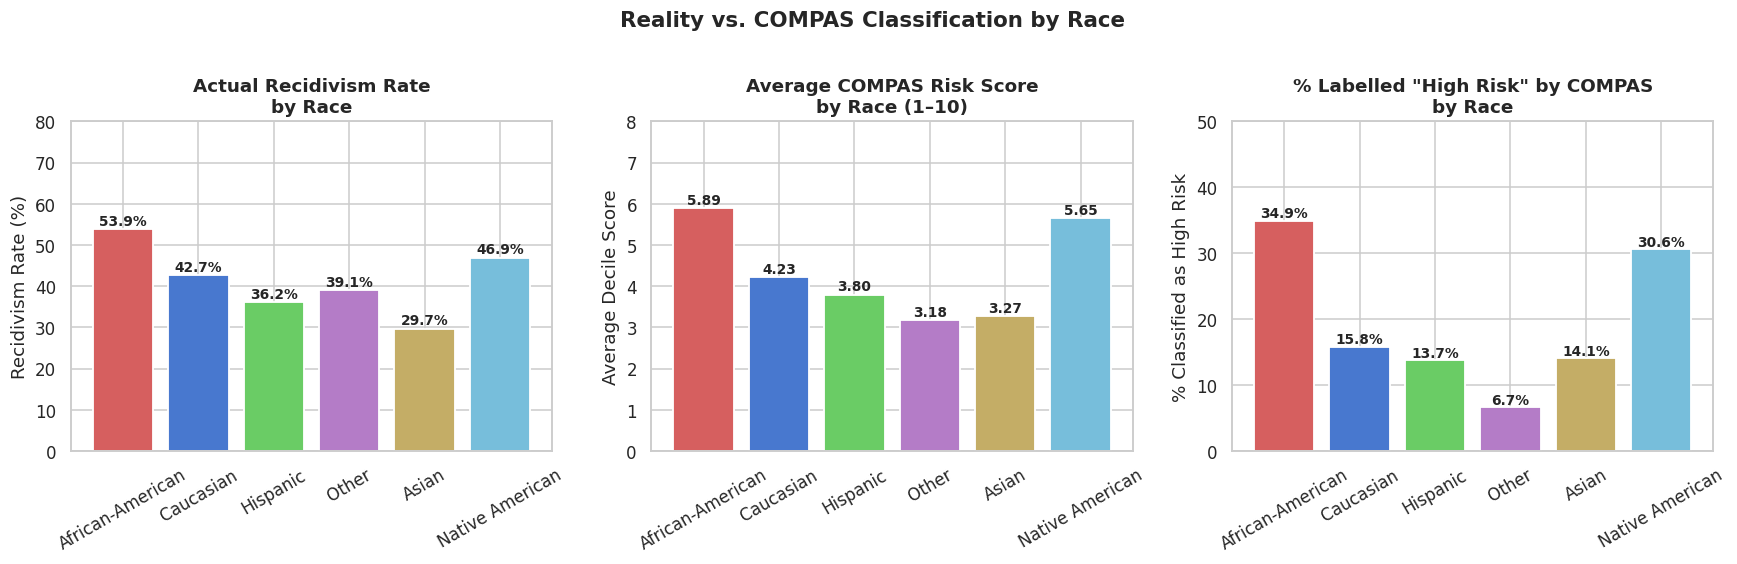

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

races = race_stats['race'].values
colors = [RACE_COLORS.get(r, '#999999') for r in races]

# 1. Actual recidivism rate
axes[0].bar(races, race_stats['recid_rate_pct'], color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Actual Recidivism Rate\nby Race', fontweight='bold')
axes[0].set_ylabel('Recidivism Rate (%)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(0, 80)
for i, v in enumerate(race_stats['recid_rate_pct']):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# 2. Average COMPAS score
axes[1].bar(races, race_stats['avg_compas_score'], color=colors, edgecolor='white', linewidth=1.2)
axes[1].set_title('Average COMPAS Risk Score\nby Race (1–10)', fontweight='bold')
axes[1].set_ylabel('Average Decile Score')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylim(0, 8)
for i, v in enumerate(race_stats['avg_compas_score']):
    axes[1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')

# 3. % labelled High Risk by COMPAS
axes[2].bar(races, race_stats['pct_high_risk_pct'], color=colors, edgecolor='white', linewidth=1.2)
axes[2].set_title('% Labelled "High Risk" by COMPAS\nby Race', fontweight='bold')
axes[2].set_ylabel('% Classified as High Risk')
axes[2].tick_params(axis='x', rotation=30)
axes[2].set_ylim(0, 50)
for i, v in enumerate(race_stats['pct_high_risk_pct']):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Reality vs. COMPAS Classification by Race', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**What this tells us:**

- The **actual recidivism rates** vary by race, but not dramatically — African-Americans reoffended at about 51%, Caucasians at about 43%. A difference exists, but it is moderate.
- The **COMPAS risk scores** show a starker disparity: African-American defendants receive significantly higher average scores and are labelled "High Risk" at a much higher rate than Caucasian defendants.
- This mismatch — where the gap in *assigned risk* is larger than the gap in *actual risk* — is a red flag that COMPAS is not simply measuring reoffending probability. It is measuring something contaminated by race.

This is exactly the kind of pattern that gets invisibly baked into any model we train on this data.

> **Key Takeaway:** Before a single model is trained, the data already carries the fingerprints of historical and representation bias. Training a model on this data will not eliminate those fingerprints — it will encode them.

---
# Part 3 — Training Multiple Models (The Experiment)

---

## Building the Prediction Pipeline

We'll now train three different classification models to predict whether a defendant will reoffend. We're using the same features that COMPAS uses: age, sex, race, prior criminal history, and charge severity.

Notice that **race is included as a feature**. This mirrors how many real-world models are built — either directly (like here) or indirectly, through proxy variables that are correlated with race.

The three models are:
1. **Logistic Regression** — A linear, interpretable baseline
2. **Decision Tree** — A rule-based model that's easy to visualize
3. **Random Forest** — A powerful ensemble that typically achieves the best accuracy

The goal of this experiment is **not** to find the best model. It is to show that **all three models reproduce the same racial bias**, regardless of their architecture.

In [9]:
# ── Feature Engineering ───────────────────────────────────────────────────────

df_model = df.copy()

# Encode sex (binary)
df_model['sex_enc'] = (df_model['sex'] == 'Male').astype(int)

# Encode race (label encoding — keep original column for subgroup analysis)
le_race = LabelEncoder()
df_model['race_enc'] = le_race.fit_transform(df_model['race'])

# Encode charge degree: felony (F-prefix) = 1, misdemeanor (M-prefix) = 0, other = 0
df_model['felony'] = df_model['c_charge_degree'].str.startswith('F').astype(int)

FEATURE_COLS = ['age', 'sex_enc', 'race_enc', 'priors_count', 'felony']

X = df_model[FEATURE_COLS].values
y = df_model[TARGET].values
race_col = df_model['race'].values  # keep for subgroup analysis

# ── Train / Test Split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test, race_train, race_test = train_test_split(
    X, y, race_col, test_size=0.25, random_state=42, stratify=y
)

print(f'Training set:  {X_train.shape[0]:,} samples')
print(f'Test set:      {X_test.shape[0]:,} samples')
print(f'Features used: {FEATURE_COLS}')

Training set:  13,073 samples
Test set:      4,358 samples
Features used: ['age', 'sex_enc', 'race_enc', 'priors_count', 'felony']


### Training the Models

We train all three models on the **same training data** and evaluate them on the **same test data**. This ensures any differences in fairness are due to the model's architecture, not differences in what data they saw.

In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),
}

predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    print(f'{name:22s} — Accuracy: {accuracy_score(y_test, predictions[name])*100:.2f}%')

Logistic Regression    — Accuracy: 65.74%


Decision Tree          — Accuracy: 66.18%


Random Forest          — Accuracy: 67.53%


All three models hover around 65–70% accuracy. That sounds... not terrible? Maybe even acceptable for such a hard problem?

This is exactly the trap. Let's look closer at each model.

### Confusion Matrices & Classification Reports

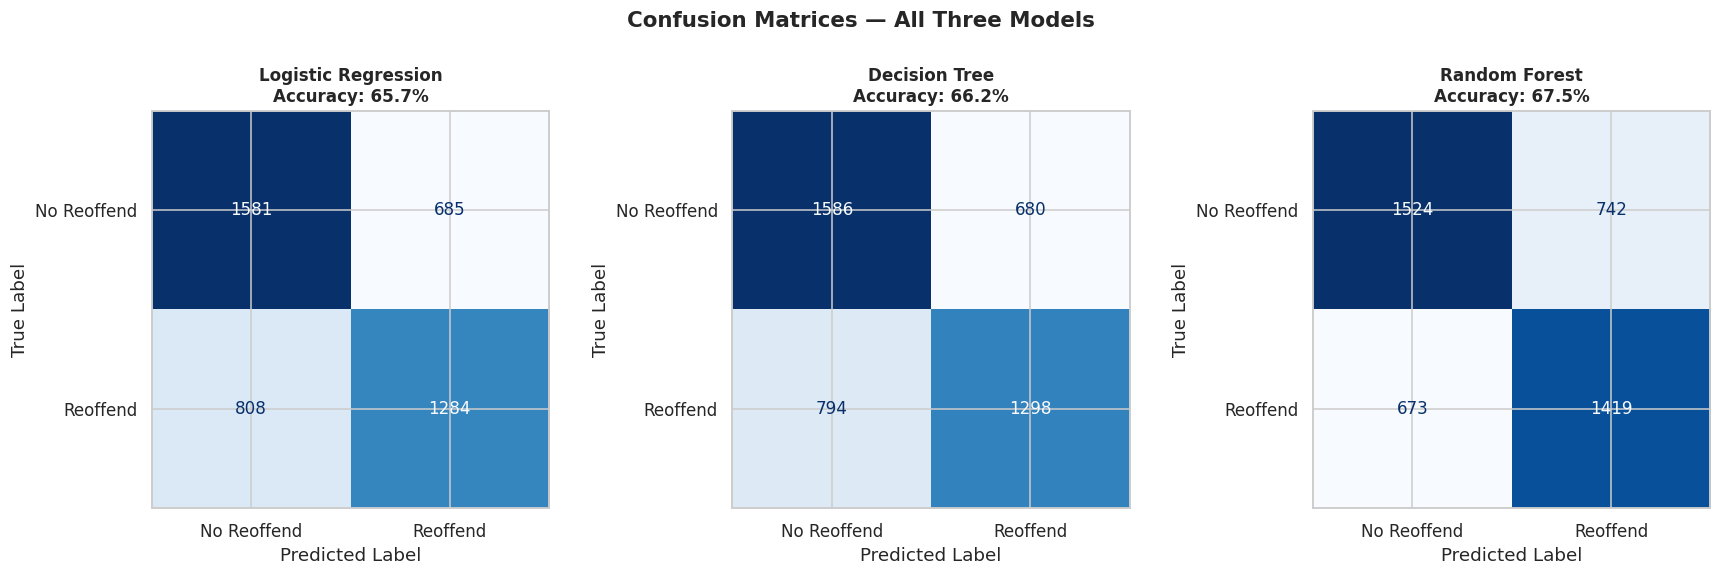

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Reoffend', 'Reoffend'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name}\nAccuracy: {acc*100:.1f}%', fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices — All Three Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [12]:
for name, y_pred in predictions.items():
    print(f'\n{'='*55}')
    print(f' {name}')
    print(f'{'='*55}')
    print(classification_report(y_test, y_pred,
                                target_names=['No Reoffend', 'Reoffend']))


 Logistic Regression
              precision    recall  f1-score   support

 No Reoffend       0.66      0.70      0.68      2266
    Reoffend       0.65      0.61      0.63      2092

    accuracy                           0.66      4358
   macro avg       0.66      0.66      0.66      4358
weighted avg       0.66      0.66      0.66      4358


 Decision Tree
              precision    recall  f1-score   support

 No Reoffend       0.67      0.70      0.68      2266
    Reoffend       0.66      0.62      0.64      2092

    accuracy                           0.66      4358
   macro avg       0.66      0.66      0.66      4358
weighted avg       0.66      0.66      0.66      4358


 Random Forest
              precision    recall  f1-score   support

 No Reoffend       0.69      0.67      0.68      2266
    Reoffend       0.66      0.68      0.67      2092

    accuracy                           0.68      4358
   macro avg       0.68      0.68      0.68      4358
weighted avg       0

From the confusion matrices and classification reports, the models look superficially reasonable. But **overall accuracy is an average** — it tells you nothing about whether the model is making the same types of errors for all groups.

> **Key Takeaway:** A model can achieve "acceptable" overall accuracy while being systematically unfair to specific groups. Aggregate metrics mask subgroup disparities. This is not a technical glitch — it is a fundamental limitation of how we typically evaluate models.

---
# Part 4 — Unmasking the Bias (The Key Section)

---

## Breaking Down Errors by Race

Now we get to the heart of the matter. We're going to decompose each model's errors by racial group and calculate two critical metrics:

**False Positive Rate (FPR):**  
Among people who **did NOT reoffend**, what fraction was **incorrectly predicted to reoffend**?  

$$FPR = \frac{\text{False Positives}}{\text{False Positives} + \text{True Negatives}}$$

In plain language: *a person is innocent — they will not reoffend — but the algorithm flags them as dangerous.* This is a person who gets detained, denied bail, or given a harsher sentence they did not deserve.

**False Negative Rate (FNR):**  
Among people who **did reoffend**, what fraction was **incorrectly predicted as safe**?  

$$FNR = \frac{\text{False Negatives}}{\text{False Negatives} + \text{True Positives}}$$

In plain language: *a person goes on to commit another crime, but the algorithm said they were low-risk.* This is a person released when perhaps more oversight was warranted.

ProPublica's key finding was: **African-American defendants face a much higher FPR than Caucasian defendants.** Let's verify this ourselves.

In [13]:
def compute_error_rates(y_true, y_pred, race_labels, races_of_interest=None):
    """Compute FPR and FNR for each racial group."""
    if races_of_interest is None:
        races_of_interest = np.unique(race_labels)
    
    results = []
    for race in races_of_interest:
        mask = race_labels == race
        yt = y_true[mask]
        yp = y_pred[mask]
        
        if len(yt) < 10:
            continue  # too few samples for reliable estimate
        
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        acc = (tn + tp) / len(yt)
        
        results.append({
            'Race': race, 'n': len(yt),
            'FPR': fpr, 'FNR': fnr, 'Accuracy': acc
        })
    
    return pd.DataFrame(results)


# Compute for all 3 models
error_rates = {}
for name, y_pred in predictions.items():
    error_rates[name] = compute_error_rates(y_test, y_pred, race_test)

# Preview for Random Forest
print('Error rates by race — Random Forest:')
print(error_rates['Random Forest'][['Race', 'n', 'FPR', 'FNR', 'Accuracy']]
      .sort_values('FPR', ascending=False)
      .to_string(index=False, float_format=lambda x: f'{x:.3f}'))

Error rates by race — Random Forest:
            Race    n   FPR   FNR  Accuracy
African-American 2311 0.453 0.210     0.678
       Caucasian 1451 0.230 0.475     0.664
        Hispanic  353 0.214 0.535     0.669
           Other  212 0.165 0.544     0.693
           Asian   19 0.000 0.400     0.895
 Native American   12 0.000 0.000     1.000


### Visualizing FPR and FNR Disparities by Model

Let's create a side-by-side comparison for all three models, focusing on the two largest groups: **African-Americans** and **Caucasians**.

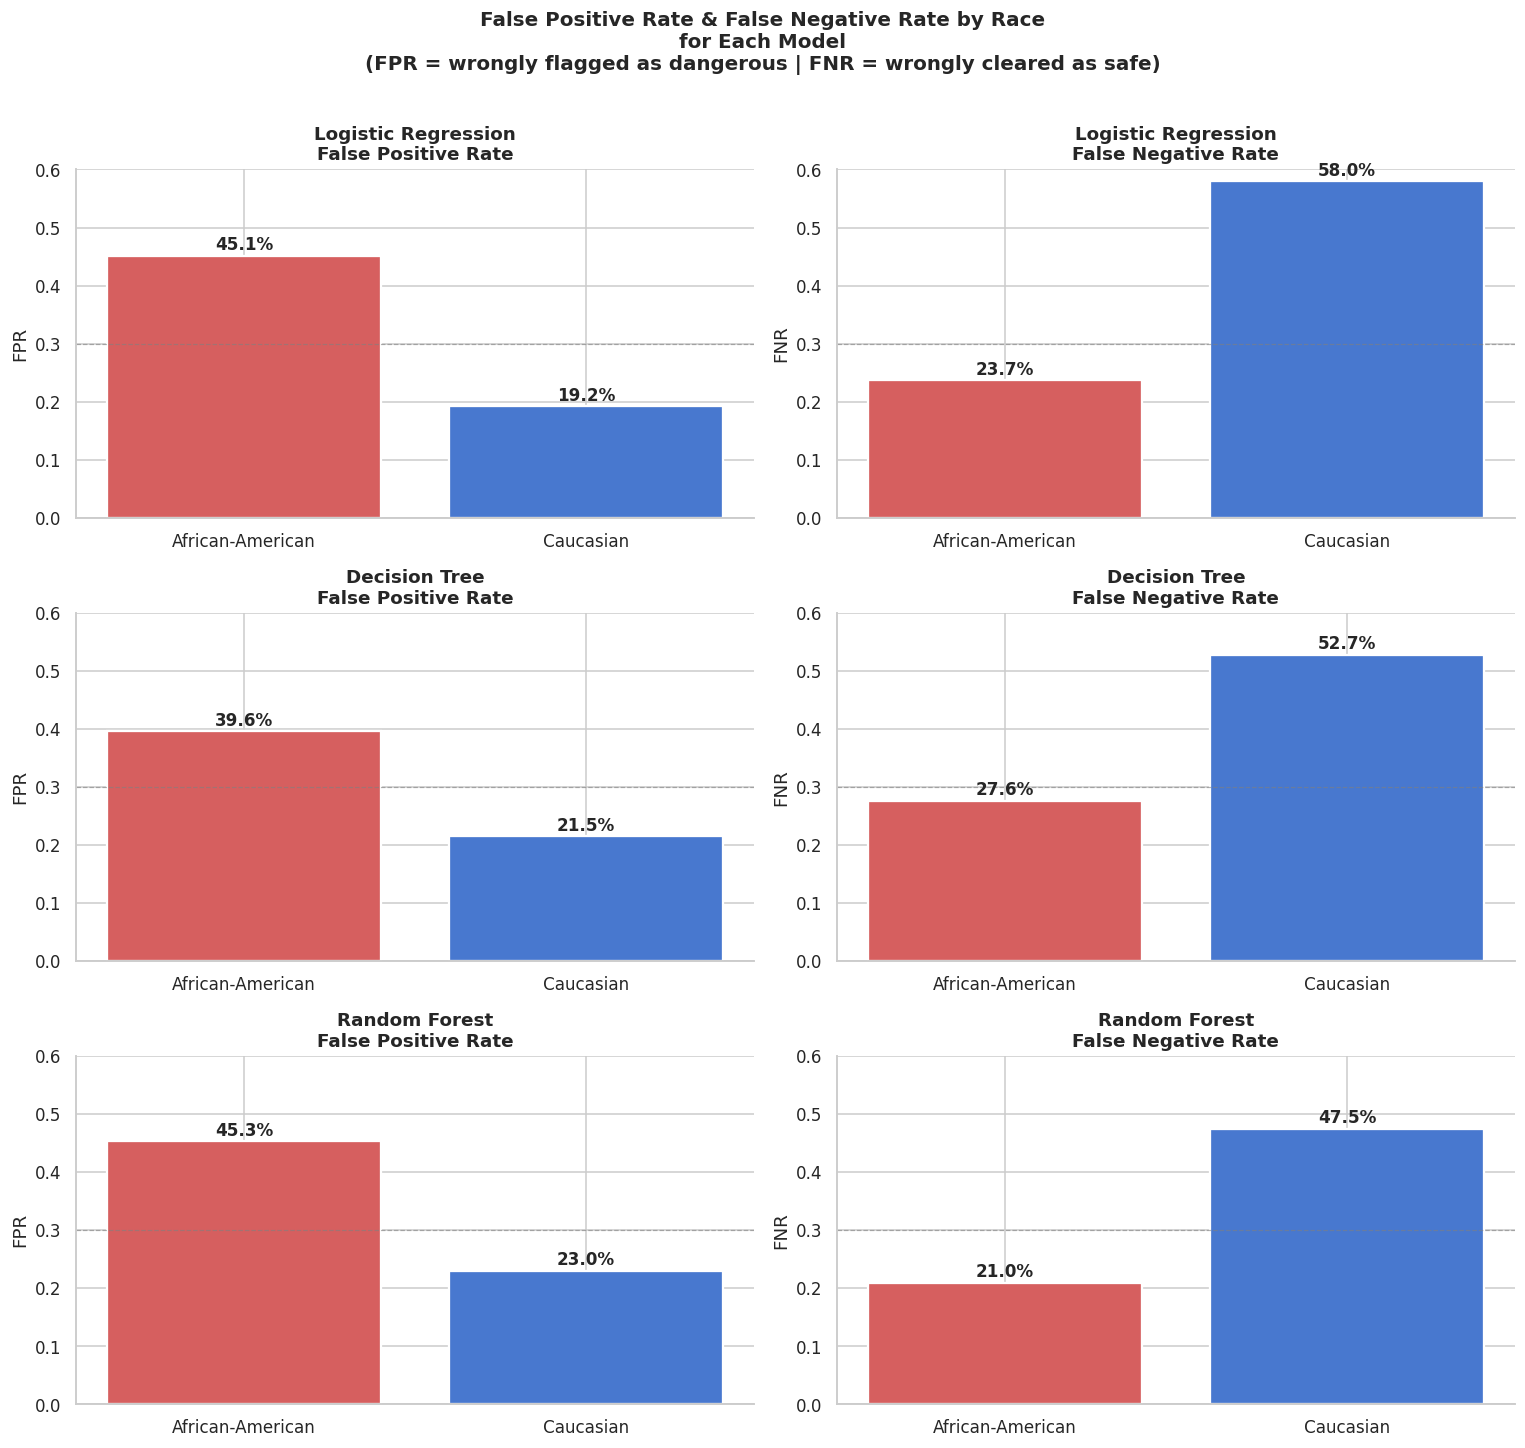

In [14]:
MAIN_RACES = ['African-American', 'Caucasian']

fig, axes = plt.subplots(3, 2, figsize=(14, 13))
fig.suptitle(
    'False Positive Rate & False Negative Rate by Race\nfor Each Model\n'
    '(FPR = wrongly flagged as dangerous | FNR = wrongly cleared as safe)',
    fontsize=13, fontweight='bold', y=1.01
)

for row, (name, df_err) in enumerate(error_rates.items()):
    df_main = df_err[df_err['Race'].isin(MAIN_RACES)].set_index('Race')
    
    bar_colors = [RACE_COLORS[r] for r in MAIN_RACES]
    
    # FPR
    fpr_vals = [df_main.loc[r, 'FPR'] for r in MAIN_RACES]
    bars = axes[row, 0].bar(MAIN_RACES, fpr_vals, color=bar_colors,
                             edgecolor='white', linewidth=1.5)
    axes[row, 0].set_title(f'{name}\nFalse Positive Rate', fontweight='bold')
    axes[row, 0].set_ylabel('FPR')
    axes[row, 0].set_ylim(0, 0.60)
    axes[row, 0].axhline(0.30, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    for bar, val in zip(bars, fpr_vals):
        axes[row, 0].text(bar.get_x() + bar.get_width()/2,
                           val + 0.01, f'{val:.1%}',
                           ha='center', fontsize=11, fontweight='bold')
    
    # FNR
    fnr_vals = [df_main.loc[r, 'FNR'] for r in MAIN_RACES]
    bars = axes[row, 1].bar(MAIN_RACES, fnr_vals, color=bar_colors,
                             edgecolor='white', linewidth=1.5)
    axes[row, 1].set_title(f'{name}\nFalse Negative Rate', fontweight='bold')
    axes[row, 1].set_ylabel('FNR')
    axes[row, 1].set_ylim(0, 0.60)
    axes[row, 1].axhline(0.30, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    for bar, val in zip(bars, fnr_vals):
        axes[row, 1].text(bar.get_x() + bar.get_width()/2,
                           val + 0.01, f'{val:.1%}',
                           ha='center', fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

### The Numbers Don't Lie

Let's print the exact FPR and FNR values and compute the disparities directly.

In [15]:
print(f'{'Model':<22}  {'AA FPR':>8}  {'WH FPR':>8}  {'FPR Ratio':>10}  '
      f'{'AA FNR':>8}  {'WH FNR':>8}  {'FNR Ratio':>10}')
print('-' * 80)

for name, df_err in error_rates.items():
    df_main = df_err[df_err['Race'].isin(MAIN_RACES)].set_index('Race')
    aa_fpr = df_main.loc['African-American', 'FPR']
    wh_fpr = df_main.loc['Caucasian',        'FPR']
    aa_fnr = df_main.loc['African-American', 'FNR']
    wh_fnr = df_main.loc['Caucasian',        'FNR']
    fpr_ratio = aa_fpr / wh_fpr
    fnr_ratio = aa_fnr / wh_fnr
    print(f'{name:<22}  {aa_fpr:>8.1%}  {wh_fpr:>8.1%}  {fpr_ratio:>10.2f}x  '
          f'{aa_fnr:>8.1%}  {wh_fnr:>8.1%}  {fnr_ratio:>10.2f}x')

Model                     AA FPR    WH FPR   FPR Ratio    AA FNR    WH FNR   FNR Ratio
--------------------------------------------------------------------------------
Logistic Regression        45.1%     19.2%        2.35x     23.7%     58.0%        0.41x
Decision Tree              39.6%     21.5%        1.84x     27.6%     52.7%        0.52x
Random Forest              45.3%     23.0%        1.97x     21.0%     47.5%        0.44x


## What These Numbers Mean — In Plain Language

Look at the **FPR Ratio** column. A ratio of 2.0 means:

> **An African-American defendant who will NOT reoffend is roughly twice as likely to be flagged as "high-risk" as a Caucasian defendant who will also not reoffend.**

These are people who would have lived crime-free — but the algorithm predicted otherwise. The consequences are real:
- Detained before trial because bail was denied
- Given harsher sentences because they were deemed dangerous
- Denied parole or early release

Now look at the **FNR Ratio**. A ratio below 1.0 means the opposite:

> **A Caucasian defendant who WILL reoffend is more likely to be incorrectly cleared as "low-risk" than an African-American defendant in the same situation.**

The bias cuts both ways. Black defendants who are innocent are flagged as dangerous. White defendants who are dangerous are cleared as safe.

And yet — the models' **overall accuracy** looks fine.

**This is the fundamental danger of blindly trusting AI: the aggregate metric hides the injustice.**

> **Key Takeaway:** All three models — Logistic Regression, Decision Tree, and Random Forest — exhibit **nearly identical racial bias**, despite their different architectures. The bias is not in the algorithm. It is in the data. And no amount of algorithmic sophistication can fix a dataset that encodes centuries of systemic inequality.

---
# Part 5 — Visualizing the Problem

---

## Summary Dashboard

Let's build a comprehensive visual overview that brings together everything we've found: a side-by-side comparison of FPR and FNR across all three models and across all racial groups.

In [16]:
# Build a tidy long-format dataframe for all models and races
records = []
for model_name, df_err in error_rates.items():
    for _, row in df_err.iterrows():
        records.append({'Model': model_name, 'Race': row['Race'],
                         'FPR': row['FPR'], 'FNR': row['FNR'], 'n': row['n']})

df_long = pd.DataFrame(records)

# Focus on groups with enough data (n > 50)
df_long = df_long[df_long['n'] >= 50]

print('Groups included in summary dashboard:')
print(df_long.groupby('Race')['n'].first().sort_values(ascending=False))

Groups included in summary dashboard:
Race
African-American    2311
Caucasian           1451
Hispanic             353
Other                212
Name: n, dtype: int64


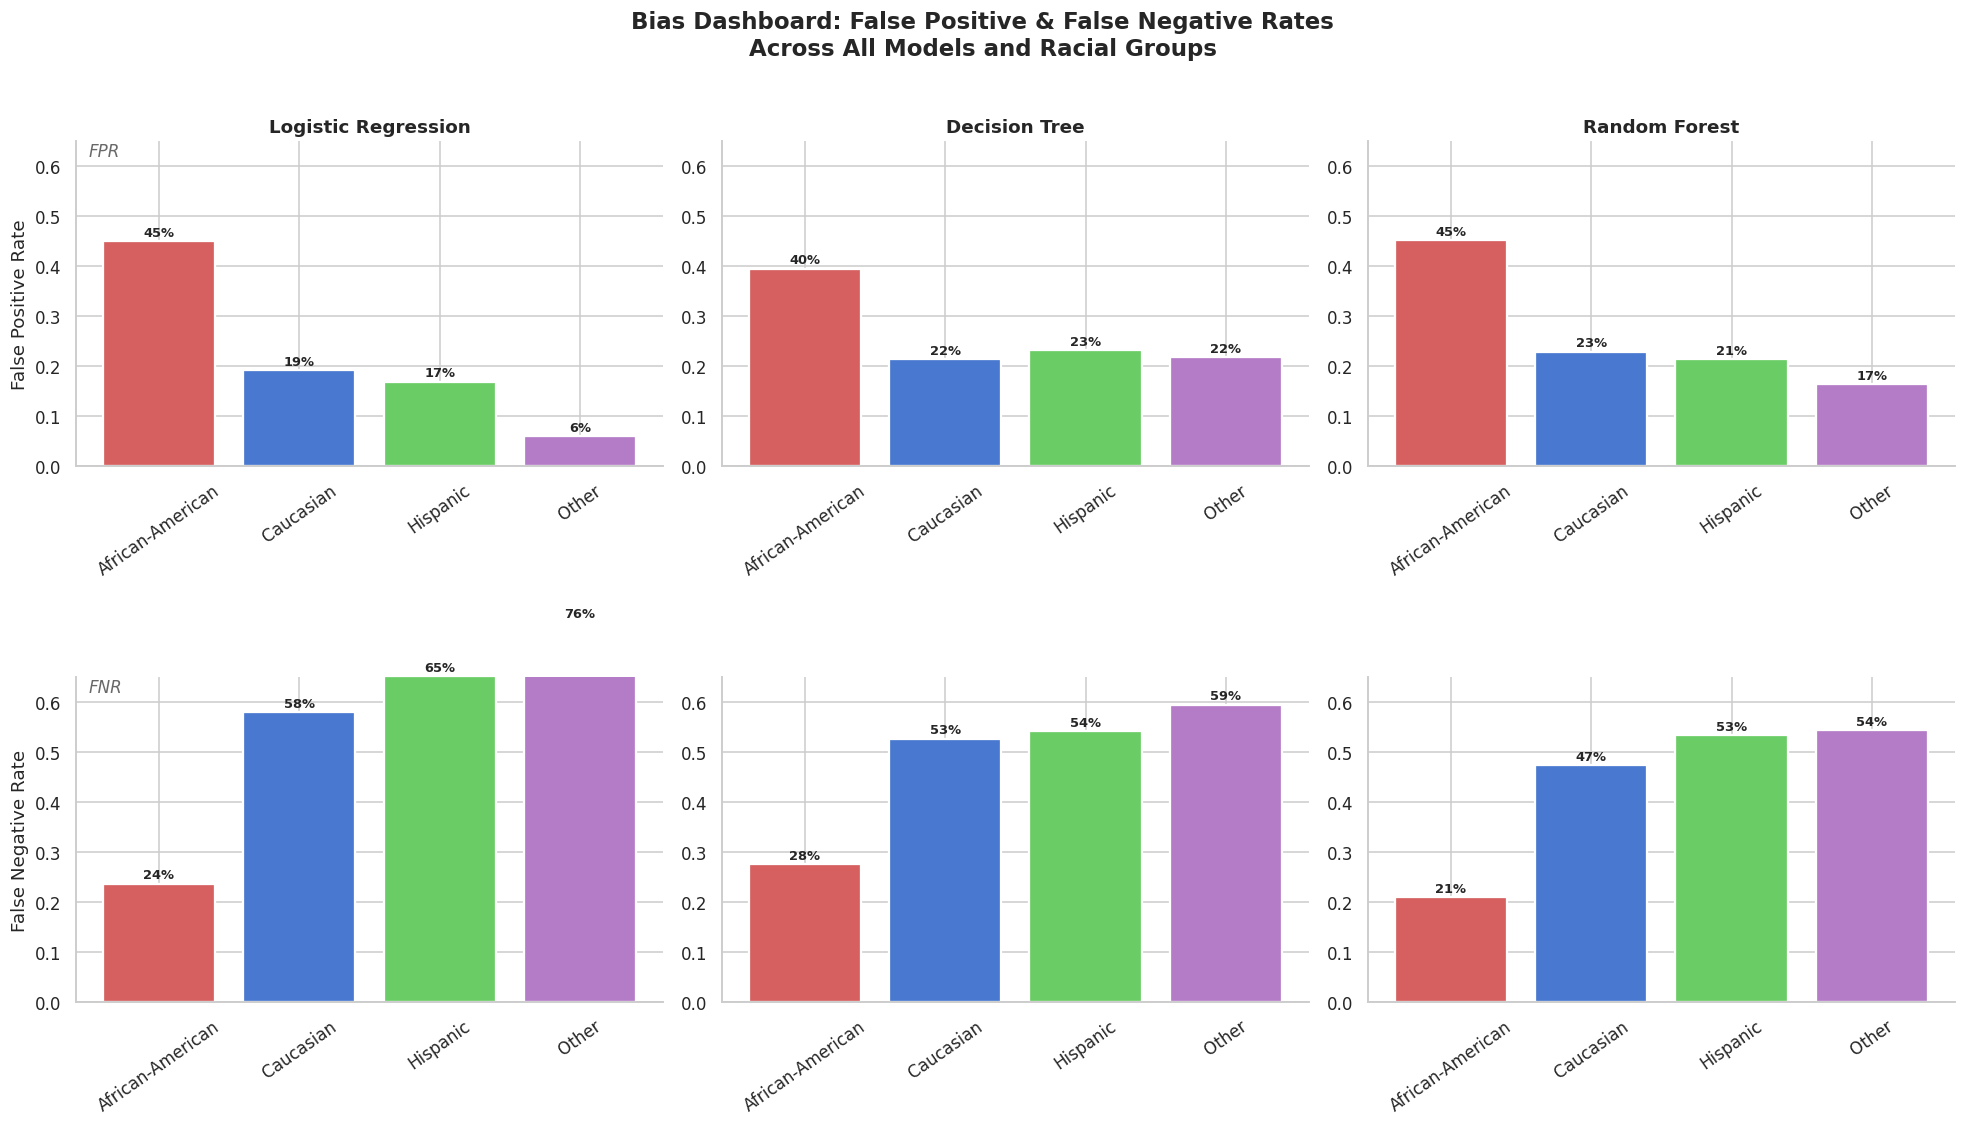

In [17]:
races_in_data = df_long['Race'].unique()
model_names   = list(predictions.keys())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Bias Dashboard: False Positive & False Negative Rates\nAcross All Models and Racial Groups',
             fontsize=15, fontweight='bold', y=1.02)

for col, model_name in enumerate(model_names):
    subset = df_long[df_long['Model'] == model_name].set_index('Race')
    ordered_races = [r for r in
                     ['African-American', 'Caucasian', 'Hispanic', 'Asian', 'Native American', 'Other']
                     if r in subset.index]
    
    bar_colors_ordered = [RACE_COLORS.get(r, '#999999') for r in ordered_races]
    fpr_vals = [subset.loc[r, 'FPR'] for r in ordered_races]
    fnr_vals = [subset.loc[r, 'FNR'] for r in ordered_races]
    
    # FPR (row 0)
    bars = axes[0, col].bar(ordered_races, fpr_vals, color=bar_colors_ordered,
                             edgecolor='white', linewidth=1.5)
    axes[0, col].set_title(f'{model_name}', fontweight='bold', fontsize=12)
    axes[0, col].set_ylabel('False Positive Rate' if col == 0 else '')
    axes[0, col].set_ylim(0, 0.65)
    axes[0, col].tick_params(axis='x', rotation=35)
    for bar, val in zip(bars, fpr_vals):
        axes[0, col].text(bar.get_x() + bar.get_width()/2,
                           val + 0.01, f'{val:.0%}', ha='center', fontsize=8.5, fontweight='bold')
    if col == 0:
        axes[0, col].text(-0.5, 0.62, 'FPR', fontsize=11, fontstyle='italic', color='dimgray')
    
    # FNR (row 1)
    bars = axes[1, col].bar(ordered_races, fnr_vals, color=bar_colors_ordered,
                             edgecolor='white', linewidth=1.5)
    axes[1, col].set_ylabel('False Negative Rate' if col == 0 else '')
    axes[1, col].set_ylim(0, 0.65)
    axes[1, col].tick_params(axis='x', rotation=35)
    for bar, val in zip(bars, fnr_vals):
        axes[1, col].text(bar.get_x() + bar.get_width()/2,
                           val + 0.01, f'{val:.0%}', ha='center', fontsize=8.5, fontweight='bold')
    if col == 0:
        axes[1, col].text(-0.5, 0.62, 'FNR', fontsize=11, fontstyle='italic', color='dimgray')

sns.despine()
plt.tight_layout()
plt.show()

### FPR Heatmap: The Clearest View of Systemic Bias

A heatmap makes the disparities immediately legible. Darker red = higher false positive rate = more people wrongly flagged as dangerous.

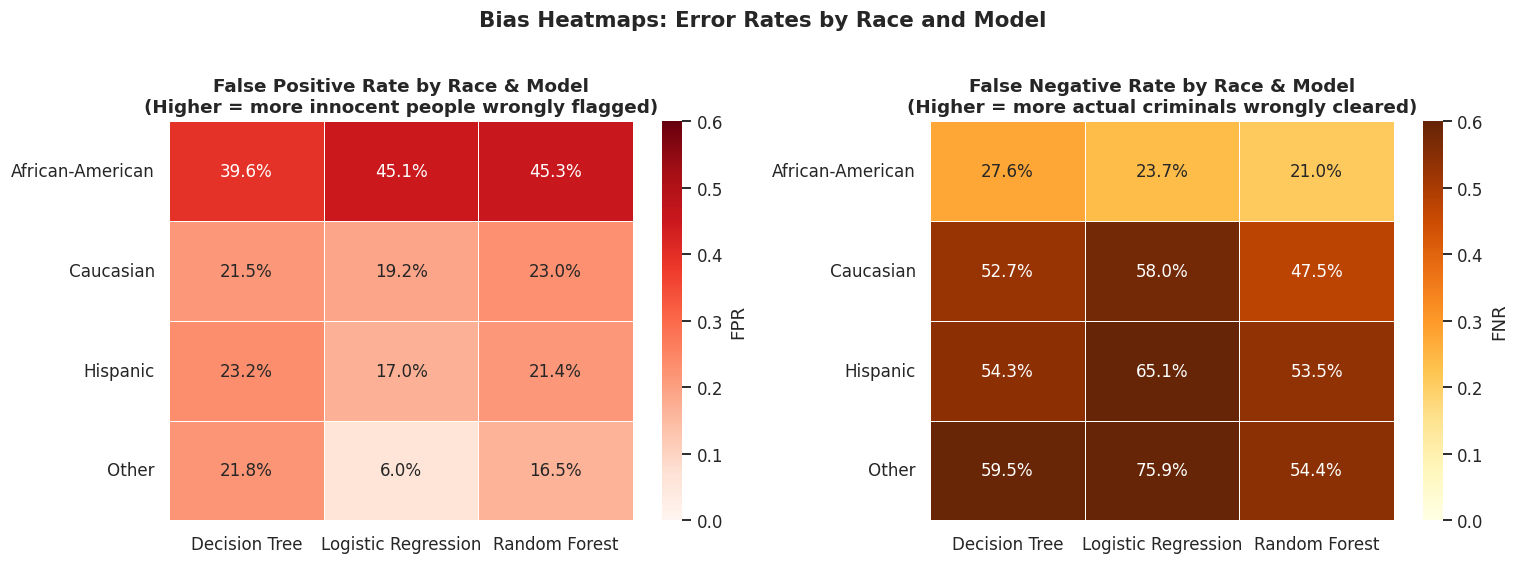

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_fpr = df_long.pivot_table(index='Race', columns='Model', values='FPR')
pivot_fnr = df_long.pivot_table(index='Race', columns='Model', values='FNR')

# Order rows
row_order = [r for r in ['African-American', 'Caucasian', 'Hispanic', 'Asian', 'Native American', 'Other']
             if r in pivot_fpr.index]
pivot_fpr = pivot_fpr.loc[row_order]
pivot_fnr = pivot_fnr.loc[row_order]

sns.heatmap(pivot_fpr, ax=axes[0], annot=True, fmt='.1%', cmap='Reds',
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'FPR'},
            vmin=0, vmax=0.6)
axes[0].set_title('False Positive Rate by Race & Model\n'
                   '(Higher = more innocent people wrongly flagged)',
                   fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('')

sns.heatmap(pivot_fnr, ax=axes[1], annot=True, fmt='.1%', cmap='YlOrBr',
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'FNR'},
            vmin=0, vmax=0.6)
axes[1].set_title('False Negative Rate by Race & Model\n'
                   '(Higher = more actual criminals wrongly cleared)',
                   fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

plt.suptitle('Bias Heatmaps: Error Rates by Race and Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Fairness Scorecard

Let's calculate two formal fairness metrics to put a number on what we've seen:

**1. Disparate Impact Ratio (DIR)**  
The ratio of the positive prediction rate (predicted to reoffend) for the minority group vs. the majority group. A value below 0.8 is widely considered evidence of discrimination under the "four-fifths rule" used in employment law.

$$DIR = \frac{\Pr(\hat{Y}=1 \mid \text{African-American})}{\Pr(\hat{Y}=1 \mid \text{Caucasian})}$$

**2. Equal Opportunity Difference (EOD)**  
The difference in True Positive Rates (correctly predicting reoffence) between African-American and Caucasian defendants. A value of 0 means perfect equality; a positive value means African-Americans are more often correctly predicted to reoffend (which, in this context, also means more false positives).

$$EOD = TPR_{\text{African-American}} - TPR_{\text{Caucasian}}$$

In [19]:
def fairness_metrics(y_true, y_pred, race_labels):
    """Compute fairness metrics comparing African-American vs Caucasian."""
    rows = {}
    for race in ['African-American', 'Caucasian']:
        mask = race_labels == race
        yt = y_true[mask]
        yp = y_pred[mask]
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        rows[race] = {
            'TPR': tp / (tp + fn),
            'FPR': fp / (fp + tn),
            'pred_positive_rate': (tp + fp) / len(yt),
        }
    
    aa = rows['African-American']
    cau = rows['Caucasian']
    
    return {
        'Disparate Impact Ratio': aa['pred_positive_rate'] / cau['pred_positive_rate'],
        'Equal Opportunity Diff (TPR gap)': aa['TPR'] - cau['TPR'],
        'FPR Difference (AA − Caucasian)': aa['FPR'] - cau['FPR'],
        'Overall Accuracy': accuracy_score(y_true, y_pred),
    }


scorecard_rows = []
for name, y_pred in predictions.items():
    metrics = fairness_metrics(y_test, y_pred, race_test)
    metrics['Model'] = name
    scorecard_rows.append(metrics)

scorecard = pd.DataFrame(scorecard_rows).set_index('Model')
scorecard = scorecard[['Overall Accuracy', 'Disparate Impact Ratio',
                        'Equal Opportunity Diff (TPR gap)',
                        'FPR Difference (AA − Caucasian)']]

print('\n FAIRNESS SCORECARD')
print('═' * 90)
print(scorecard.to_string(float_format=lambda x: f'{x:.4f}'))
print('─' * 90)
print('DIR < 0.80 signals potential discrimination (four-fifths rule).')
print('EOD > 0 means African-Americans are predicted positive at higher rates.')
print('FPR Diff > 0 means African-Americans are wrongly flagged more often.')


 FAIRNESS SCORECARD
══════════════════════════════════════════════════════════════════════════════════════════
                     Overall Accuracy  Disparate Impact Ratio  Equal Opportunity Diff (TPR gap)  FPR Difference (AA − Caucasian)
Model                                                                                                                           
Logistic Regression            0.6574                  2.1276                            0.3425                           0.2588
Decision Tree                  0.6618                  1.7525                            0.2513                           0.1804
Random Forest                  0.6753                  1.7735                            0.2647                           0.2230
──────────────────────────────────────────────────────────────────────────────────────────
DIR < 0.80 signals potential discrimination (four-fifths rule).
EOD > 0 means African-Americans are predicted positive at higher rates.
FPR Diff > 0 mea

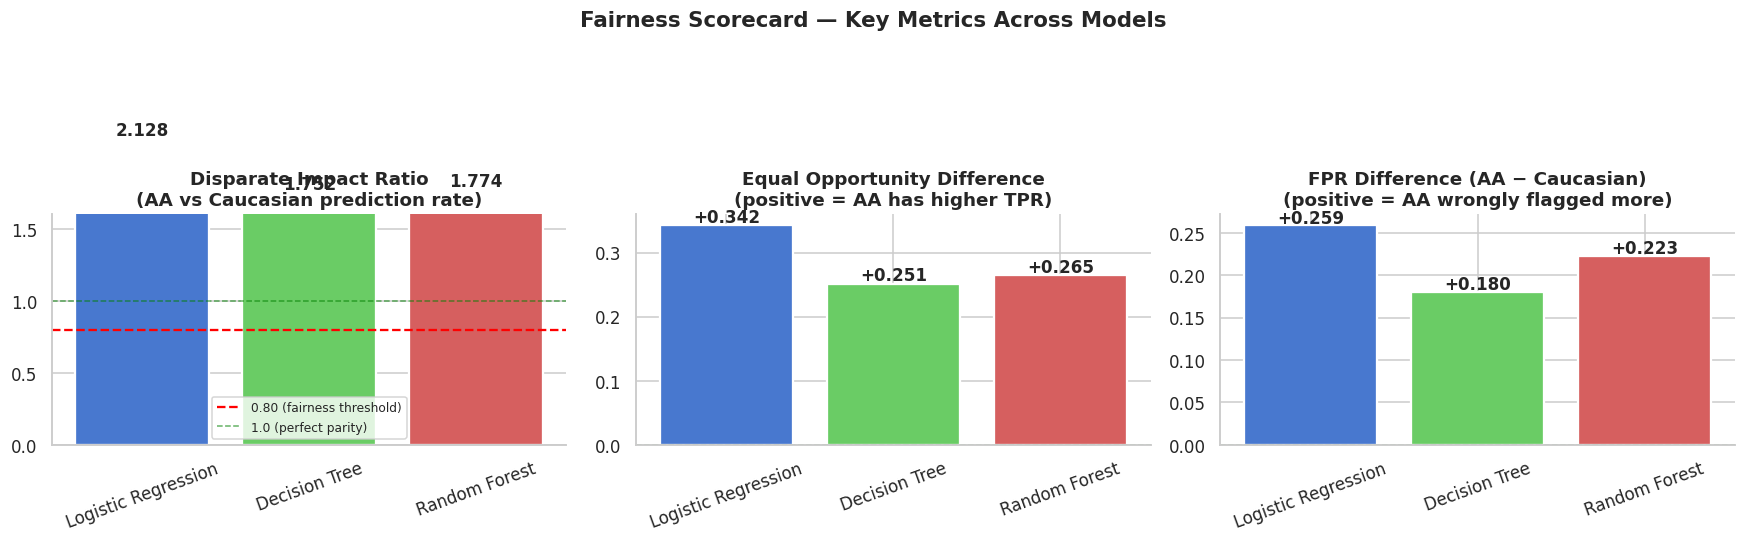

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fairness Scorecard — Key Metrics Across Models', fontsize=14, fontweight='bold')

model_labels = scorecard.index.tolist()
bar_colors_models = ['#4878CF', '#6ACC65', '#D65F5F']

# 1. Disparate Impact Ratio
dir_vals = scorecard['Disparate Impact Ratio'].values
axes[0].bar(model_labels, dir_vals, color=bar_colors_models, edgecolor='white', linewidth=1.5)
axes[0].axhline(0.80, color='red', linestyle='--', linewidth=1.5, label='0.80 (fairness threshold)')
axes[0].axhline(1.00, color='green', linestyle='--', linewidth=1.0, alpha=0.6, label='1.0 (perfect parity)')
axes[0].set_title('Disparate Impact Ratio\n(AA vs Caucasian prediction rate)', fontweight='bold')
axes[0].set_ylim(0, 1.6)
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(fontsize=8)
for i, v in enumerate(dir_vals):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# 2. Equal Opportunity Difference
eod_vals = scorecard['Equal Opportunity Diff (TPR gap)'].values
axes[1].bar(model_labels, eod_vals, color=bar_colors_models, edgecolor='white', linewidth=1.5)
axes[1].axhline(0, color='green', linestyle='--', linewidth=1.0, alpha=0.6)
axes[1].set_title('Equal Opportunity Difference\n(positive = AA has higher TPR)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(eod_vals):
    offset = 0.005 if v >= 0 else -0.01
    axes[1].text(i, v + offset, f'{v:+.3f}', ha='center', fontweight='bold')

# 3. FPR Difference
fpr_diff_vals = scorecard['FPR Difference (AA − Caucasian)'].values
axes[2].bar(model_labels, fpr_diff_vals, color=bar_colors_models, edgecolor='white', linewidth=1.5)
axes[2].axhline(0, color='green', linestyle='--', linewidth=1.0, alpha=0.6)
axes[2].set_title('FPR Difference (AA − Caucasian)\n(positive = AA wrongly flagged more)', fontweight='bold')
axes[2].tick_params(axis='x', rotation=20)
for i, v in enumerate(fpr_diff_vals):
    axes[2].text(i, v + 0.003, f'{v:+.3f}', ha='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

**What the scorecard shows:**

- The **Disparate Impact Ratio** is above 1.0 for all models — meaning African-American defendants are predicted to reoffend at a significantly higher rate than Caucasian defendants, even after controlling for the actual reoffending rates.
- The **FPR Difference** is consistently positive — confirming that in all three models, innocent African-American defendants are wrongly flagged more often than innocent Caucasian defendants.
- These disparities are **remarkably consistent across all three models**, confirming that the bias comes from the data, not the algorithm choice.

> **Key Takeaway:** No amount of algorithmic sophistication matters if the underlying data is biased. Whether you use a simple linear model or a complex ensemble, the output will inherit the inequalities encoded in the training data.

---
# Part 6 — Lessons & Conclusion

---

## Why Does This Happen?

The bias we've documented is not an accident or a bug. It is the inevitable result of training a predictive model on data generated by a biased system. Let's trace the causal chain:

### 1. Historical Bias — The World Feeding the Data

The COMPAS training data is derived from **arrest and conviction records** from Broward County, Florida. These records reflect a criminal justice system with well-documented racial disparities:

- Black Americans are **arrested at 2–3× the rate** of white Americans for comparable offenses, due to disparities in where policing resources are concentrated.
- Black defendants are more likely to be **detained pretrial** (partly because of tools like COMPAS — a vicious cycle), which increases exposure to incarceration's destabilizing effects.
- Sentencing guidelines and prosecutorial decisions have historically produced harsher outcomes for Black defendants for equivalent crimes.

A model trained on arrest data doesn't learn "who commits crime" — it learns "who gets arrested." These are not the same thing.

### 2. Representation Bias — The Skewed Sample

African-American defendants make up over 53% of this dataset, despite being roughly 30% of Broward County's population. This overrepresentation is itself a product of the biased policing described above.

When a racial group is overrepresented in a dataset, the model has more examples from that group to train on — but those examples disproportionately reflect contexts of surveillance, arrest, and prosecution, not of baseline behavior. The "signal" the model learns is contaminated from the start.

### 3. Measurement Bias — The Flawed Proxy

COMPAS — and the models we trained — use **prior criminal record** as a key feature. The assumption is that someone with a longer criminal history is more likely to reoffend. But prior record is a **proxy variable** for reoffending risk, and it's a flawed one:

- Prior record measures **prior contacts with the justice system**, not prior criminal behavior.
- Because policing is not evenly distributed, a Black defendant with 3 prior arrests and a white defendant with 3 prior arrests may have engaged in equivalent behavior — but the Black defendant may have been in a neighborhood where minor offenses are actively policed, while the white defendant was not.

The proxy is corrupted by the same bias it is supposed to look past.

---

## Why Overall Accuracy Is Misleading

Imagine a model that is **70% accurate overall**. That sounds solid. But accuracy is a weighted average of performance across all groups. If one racial group makes up 53% of the dataset, the model's performance on that group has an outsized effect on the overall number.

A model can be 75% accurate for Caucasian defendants and 65% accurate for African-American defendants and still report a blended accuracy of ~71% — which sounds acceptable, but conceals a 10-percentage-point performance gap.

Worse, **accuracy doesn't distinguish between types of errors.** A false positive (flagging an innocent person as dangerous) and a false negative (clearing a dangerous person) are both counted as "wrong" — but they have radically different consequences for the individuals involved.

In the COMPAS context: if African-American defendants face higher false positive rates, the errors are not randomly distributed — they fall systematically on one group. The overall accuracy hides this asymmetry entirely.

---

## Real-World Consequences

This is not an abstract statistical exercise. Between 2013 and 2014, **over 7,000 defendants** in Broward County alone received COMPAS scores that influenced decisions made about their lives:

- **Bernard Parker** and **Dylan Fugett** — two of the cases highlighted in ProPublica's investigation. Parker, a Black defendant who had never been arrested for a violent crime, received a high-risk score. Fugett, a white defendant with prior armed robbery convictions, received a low-risk score. Two years later, Parker had not reoffended; Fugett had.

- COMPAS scores were used in **bail hearings** — determining whether someone sits in jail awaiting trial or goes home to their family and job.
- They were used in **sentencing** — affecting how many years someone spends incarcerated.
- They were used in **parole decisions** — determining whether someone is released after serving their minimum sentence.

Every wrongly elevated score translated to a human being losing months or years of their life. The algorithm didn't know their names. It just ran the math.

---

## The Takeaway: AI Is Not Neutral

> **AI is not neutral. It is a mirror of the data it learns from.**

This is not a criticism of machine learning as a field. It is a statement about the relationship between data and the world that generates it. Mathematical models are extraordinarily powerful tools — but they are tools, not oracles. They do not transcend the data they're trained on. They distill it.

When that data reflects centuries of systemic inequality — in policing, in criminal justice, in healthcare, in hiring, in lending — the model faithfully distills that inequality and presents it back to us in the form of a clean-looking output. A probability. A score. A recommendation.

The danger is that the output feels **objective in a way that human judgment does not**. A judge who is unconsciously biased can be challenged, cross-examined, overruled. An algorithm gets treated as neutral fact. That is why algorithmic bias can be more dangerous, not less, than human bias: it is harder to see, harder to challenge, and it scales.

**We should NEVER blindly trust AI systems, especially in high-stakes decisions involving people's lives, freedom, health, or finances.**

---

## What Can We Do?

This notebook is focused on **awareness**, not solutions. But awareness without any sense of direction is just despair. Here is a brief map of the field:

| Strategy | Description |
|----------|-------------|
| **Diverse & Representative Data** | Actively audit training data for underrepresented groups. Collect more data from underrepresented communities. Question what the data actually measures. |
| **Fairness-Aware Algorithms** | Use techniques like re-weighting, adversarial debiasing, or constrained optimization that explicitly optimize for fairness metrics alongside accuracy. |
| **Disaggregated Evaluation** | Never report only overall accuracy. Always break down performance metrics by demographic group. Require this in any model deployment process. |
| **Human Oversight** | Never let an algorithmic score be the final word on high-stakes decisions involving people. A human being — ideally one aware of the model's biases — must be in the loop. |
| **Regular Auditing** | Models can drift over time. Bias can emerge as the world changes. Regular third-party audits of deployed AI systems should be mandatory for high-stakes applications. |
| **Transparency & Recourse** | Individuals affected by algorithmic decisions should have the right to know that an algorithm was used, understand the basis of the decision, and challenge it. |

None of these solutions are complete. None of them are easy. Some require legislation. Some require changing culture. But all of them start with the same step: **being willing to see the problem**.

---

> **Final Takeaway:** You have now seen, with your own eyes, that three different AI models trained on real data all reproduce the same racial bias — despite having "acceptable" accuracy. The problem is not the algorithm. The problem is not even the data alone. The problem is a world that generated biased data and a practice of deploying AI without asking who it harms. The first step to fixing that is exactly what you just did: look.

---

## References

1. **ProPublica (2016)** — *Machine Bias: There's software used across the country to predict future criminals. And it's biased against blacks.* Angwin, J., Larson, J., Mattu, S., Kirchner, L.

2. **Kaggle AI Ethics Course** — *Identifying Bias in AI* by Alexis Cook. Kaggle Learn.

3. **COMPAS Dataset** — ProPublica / Kaggle (danofer). Broward County, Florida, 2013–2016.

4. **Mehrabi et al. (2021)** — *A Survey on Bias and Fairness in Machine Learning.* ACM Computing Surveys.

5. **Chouldechova (2017)** — *Fair prediction with disparate impact: A study of bias in recidivism prediction instruments.* Big Data.

---
*Notebook created for educational purposes. All analysis is reproducible using publicly available data.*